# Entrenamiento e Inferencia YOLOv8 — Detección de Instrumentos Quirúrgicos

Se Entrena el modelo sobre el dataset de instrumentos quirúrgicos, además se realiza un inferencia
para identificar entre los intrumentos: (bisturís, pinzas y tijeras) en las imagenes.

## 1. Importaciones

In [10]:
from ultralytics import YOLO
import os
import cv2
import random
import matplotlib.pyplot as plt

## 2. Verificar que el dataset está listo

In [11]:
yaml_path = 'data.yaml'

if os.path.exists(yaml_path):
    print('data.yaml encontrado')
    with open(yaml_path, 'r') as f:
        print(f.read())
else:
    print( 'No se encontró data.yaml. Corre primero generate_dataset_yolo.ipynb')

data.yaml encontrado
path: C:\Universidad\Curso IA\Proyecto\dataset_yolo
train: train/images
val: val/images

nc: 4
names:
  - Scalpel
  - Straight_Dissection_Clamp
  - Straight_Mayo_Scissor
  - Curved_Mayo_Scissor



## 3. Configuración del experimento

In [12]:
# ─── PARÁMETROS ───────────────────────────────────────────────────────────────
NOMBRE_EXPERIMENTO = 'experimento_1' 
EPOCHS             = 30
BATCH_SIZE         = 8    
IMG_SIZE           = 320
DATA_YAML          = 'data.yaml'
# ─────────────────────────────────────────────────────────────────────────────

print(f'Experimento: {NOMBRE_EXPERIMENTO}')
print(f'Épocas: {EPOCHS} | Batch: {BATCH_SIZE} | Tamaño imagen: {IMG_SIZE}')

Experimento: experimento_1
Épocas: 30 | Batch: 8 | Tamaño imagen: 320


## 4. Entrenar el modelo

In [13]:
# Cargar modelo base YOLOv8 nano
modelo = YOLO('yolov8n.pt')

resultados = modelo.train(
    data     = DATA_YAML,
    epochs   = EPOCHS,
    batch    = BATCH_SIZE,
    imgsz    = IMG_SIZE,
    project  = 'runs/detect',
    name     = NOMBRE_EXPERIMENTO,
    plots    = True,
    save     = True,
    patience = 20
)

print('\nEntrenamiento finalizado')

New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.0  Python-3.10.11 torch-2.3.1+cpu CPU (12th Gen Intel Core(TM) i5-12500H)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=data.yaml, epochs=30, time=None, patience=20, batch=8, imgsz=320, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/detect, name=experimento_14, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, sav

train: Scanning C:\Universidad\Curso IA\Proyecto\dataset_yolo\train\labels.cache... 2893 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2893/2893 [00:00<?, ?it/s]
val: Scanning C:\Universidad\Curso IA\Proyecto\dataset_yolo\val\labels.cache... 1088 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1088/1088 [00:00<?, ?it/s]


Plotting labels to runs\detect\experimento_14\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 320 train, 320 val
Using 0 dataloader workers
Logging results to runs\detect\experimento_14
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/30         0G      1.456      2.488       1.33          8        320: 100%|██████████| 362/362 [04:10<00:00,  1.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 68/68 [00:43<00:00,  1.58it/s]


                   all       1088       1519      0.395        0.6        0.4      0.278

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      30/30         0G     0.5286     0.5624     0.8918          6        320: 100%|██████████| 362/362 [04:50<00:00,  1.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 68/68 [00:37<00:00,  1.79it/s]

                   all       1088       1519      0.908      0.904       0.97      0.868



30 epochs completed in 2.770 hours.
Optimizer stripped from runs\detect\experimento_14\weights\last.pt, 6.2MB
Optimizer stripped from runs\detect\experimento_14\weights\best.pt, 6.2MB

Validating runs\detect\experimento_14\weights\best.pt...
Ultralytics YOLOv8.2.0  Python-3.10.11 torch-2.3.1+cpu CPU (12th Gen Intel Core(TM) i5-12500H)
Model summary (fused): 168 layers, 3006428 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 68/68 [00:35<00:00,  1.90it/s]


                   all       1088       1519      0.907      0.904       0.97      0.868
               Scalpel       1088        376       0.95      0.912      0.978      0.833
Straight_Dissection_Clamp       1088        374       0.94      0.856      0.965      0.812
 Straight_Mayo_Scissor       1088        373      0.912       0.89      0.965      0.904
   Curved_Mayo_Scissor       1088        396      0.825      0.957      0.971      0.925
Speed: 0.6ms preprocess, 20.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs\detect\experimento_14

Entrenamiento finalizado


## 5. Ver métricas del entrenamiento

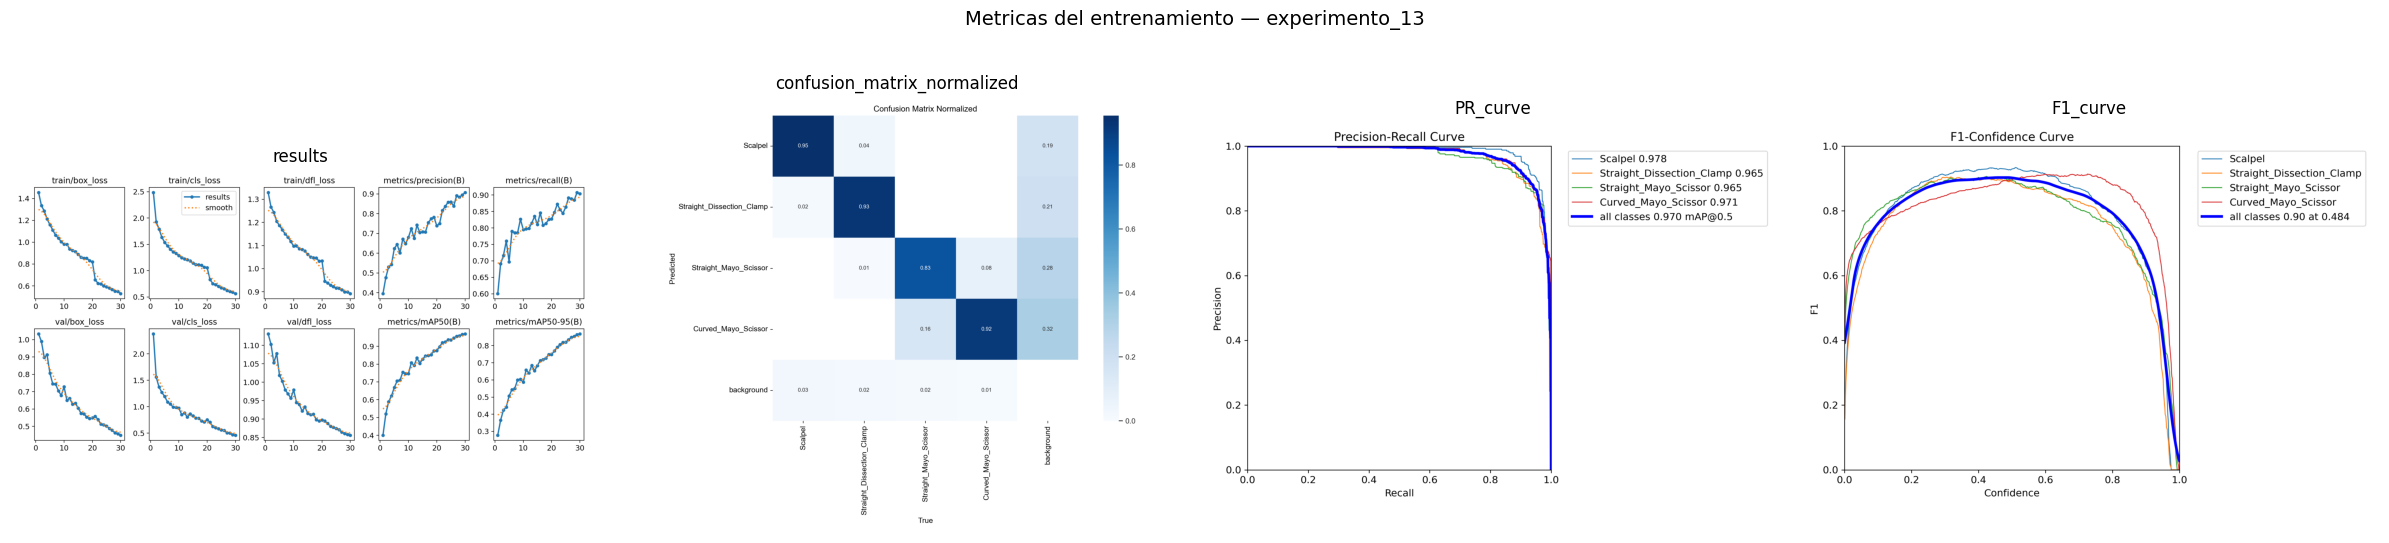

In [14]:
NOMBRE_EXPERIMENTO = 'experimento_13'
ruta_experimento   = f'runs/detect/{NOMBRE_EXPERIMENTO}'

# Mostrar gráficas de resultados
graficas = ['results.png', 'confusion_matrix_normalized.png', 'PR_curve.png', 'F1_curve.png']

fig, axes = plt.subplots(1, len(graficas), figsize=(24, 6))

for ax, nombre_grafica in zip(axes, graficas):
    ruta = os.path.join(ruta_experimento, nombre_grafica)
    if os.path.exists(ruta):
        img = cv2.imread(ruta)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(nombre_grafica.replace('.png', ''))
        ax.axis('off')
    else:
        ax.set_title(f'No encontrada: {nombre_grafica}')
        ax.axis('off')

plt.suptitle(f'Metricas del entrenamiento — {NOMBRE_EXPERIMENTO}', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Evaluar en validación

In [15]:
ruta_mejor_modelo = f'runs/detect/{NOMBRE_EXPERIMENTO}/weights/best.pt'
modelo_entrenado  = YOLO(ruta_mejor_modelo)

metricas = modelo_entrenado.val(data=DATA_YAML)

print('── Métricas en Validación ──')
print(f'mAP@0.5:      {metricas.box.map50:.4f}')
print(f'mAP@0.5:0.95: {metricas.box.map:.4f}')
print(f'Precisión:    {metricas.box.mp:.4f}')
print(f'Recall:       {metricas.box.mr:.4f}')

Ultralytics YOLOv8.2.0  Python-3.10.11 torch-2.3.1+cpu CPU (12th Gen Intel Core(TM) i5-12500H)
Model summary (fused): 168 layers, 3006428 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning C:\Universidad\Curso IA\Proyecto\dataset_yolo\val\labels.cache... 1088 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1088/1088 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 68/68 [00:31<00:00,  2.17it/s]


                   all       1088       1519      0.907      0.904       0.97      0.868
               Scalpel       1088        376       0.95      0.912      0.978      0.833
Straight_Dissection_Clamp       1088        374       0.94      0.856      0.965      0.812
 Straight_Mayo_Scissor       1088        373      0.912       0.89      0.965      0.904
   Curved_Mayo_Scissor       1088        396      0.825      0.957      0.971      0.925
Speed: 0.5ms preprocess, 18.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to c:\Universidad\Curso IA\Proyecto\runs\detect\val2
── Métricas en Validación ──
mAP@0.5:      0.9699
mAP@0.5:0.95: 0.8684
Precisión:    0.9070
Recall:       0.9037


## 7. Inferencia sobre imágenes de prueba

In [16]:
clases = open('classes.txt').read().strip().split('\n')

imagenes_prueba = [
    os.path.join('test_images', f)
    for f in os.listdir('test_images')
    if f.endswith(('.jpg', '.jpeg', '.png'))
]

print(f'{len(imagenes_prueba)} imágenes de prueba encontradas')

4 imágenes de prueba encontradas



0: 320x320 2 Scalpels, 2 Curved_Mayo_Scissors, 22.7ms
1: 320x320 (no detections), 22.7ms
2: 320x320 1 Straight_Dissection_Clamp, 22.7ms
3: 320x320 1 Curved_Mayo_Scissor, 22.7ms
Speed: 1.2ms preprocess, 22.7ms inference, 1.5ms postprocess per image at shape (1, 3, 320, 320)
Results saved to runs\detect\inferencia_instrumentos2


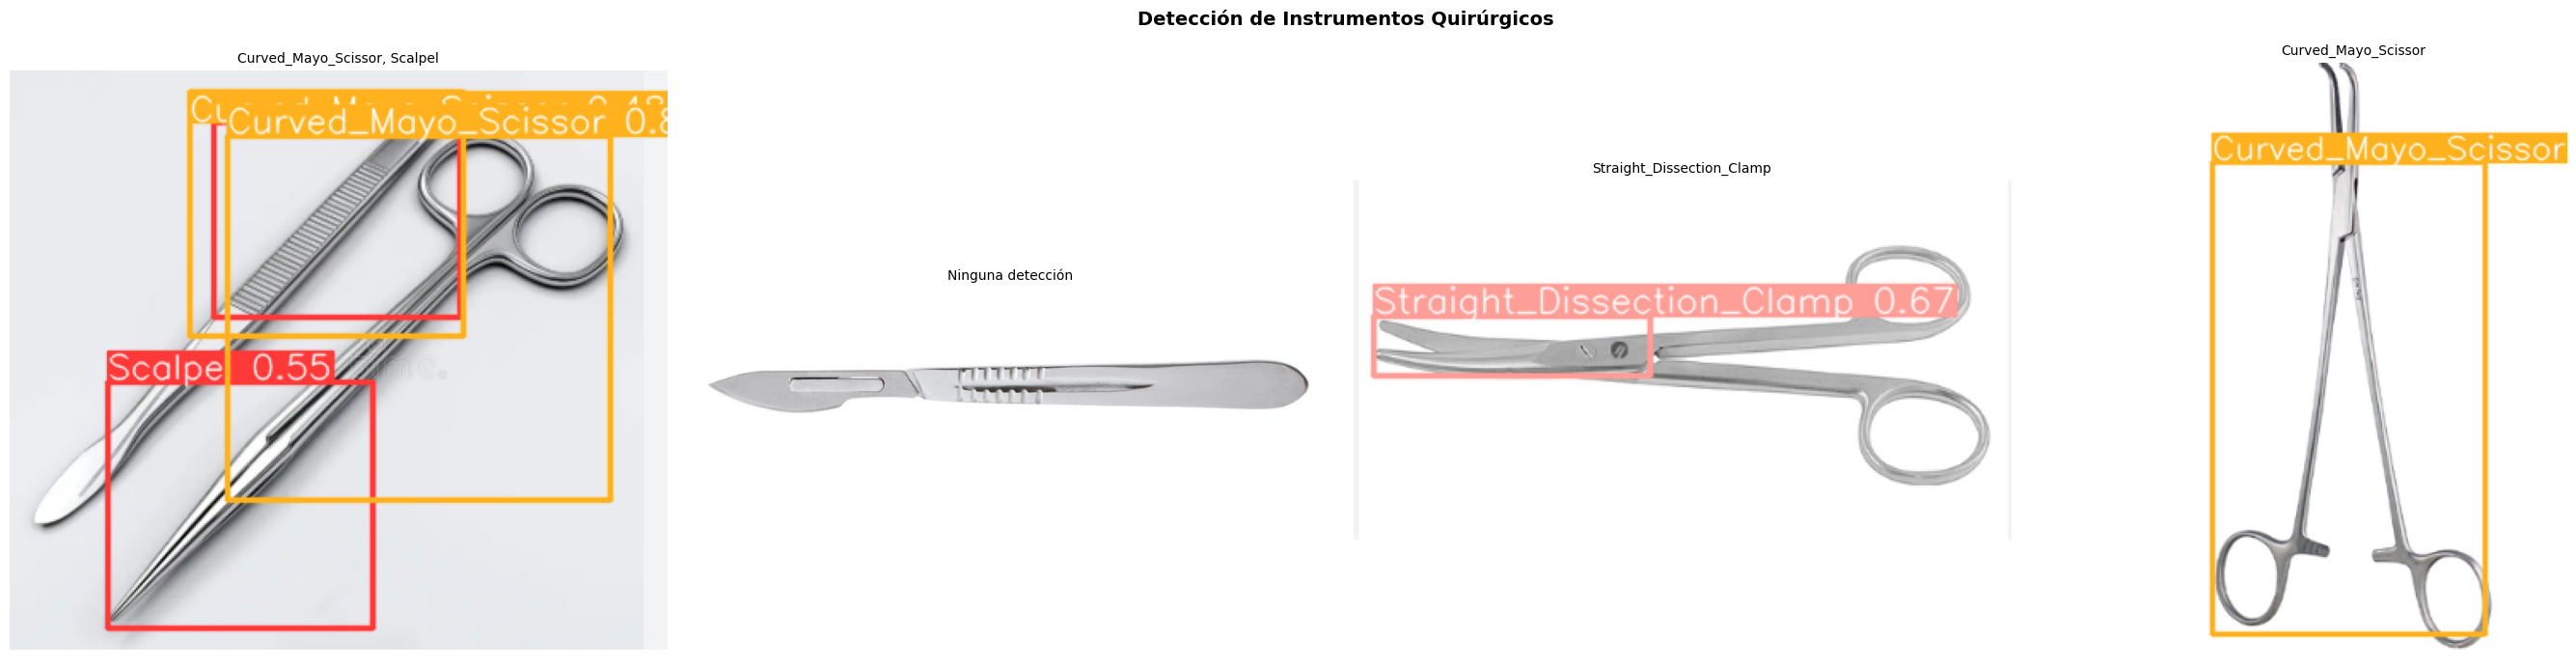

In [17]:
predicciones = modelo_entrenado.predict(
    source  = imagenes_prueba,
    conf    = 0.4,
    iou     = 0.5,
    save    = True,
    project = 'runs/detect',
    name    = 'inferencia_instrumentos'
)

# Mostrar resultados
n = len(predicciones)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
if n == 1:
    axes = [axes]

for ax, resultado in zip(axes, predicciones):
    img_rgb = cv2.cvtColor(resultado.plot(), cv2.COLOR_BGR2RGB)
    clases_detectadas = [clases[int(c)] for c in resultado.boxes.cls]
    resumen = ', '.join(set(clases_detectadas)) if clases_detectadas else 'Ninguna detección'
    ax.imshow(img_rgb)
    ax.set_title(resumen, fontsize=10)
    ax.axis('off')

plt.suptitle('Detección de Instrumentos Quirúrgicos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Reporte de instrumentos detectados por imagen

In [18]:
print('══════════════════════════════════════════════')
print('   REPORTE DE DETECCIÓN — BANDEJA QUIRÚRGICA')
print('══════════════════════════════════════════════\n')

# Instrumentos que deben estar presentes en la bandeja
bandeja_esperada = {'Scalpel', 'Straight_Dissection_Clamp', 'Straight_Mayo_Scissor'}

for i, resultado in enumerate(predicciones):
    detectados = set(clases[int(c)] for c in resultado.boxes.cls)
    presentes  = detectados & bandeja_esperada
    faltantes  = bandeja_esperada - detectados

    print(f'Imagen {i+1}: {imagenes_prueba[i]}')
    print(f'  Instrumentos detectados: {detectados if detectados else "Ninguno"}')
    print(f'  De la bandeja esperada:  {presentes if presentes else "Ninguno"}')
    print(f'  Faltantes en bandeja:    {faltantes if faltantes else "Ninguno"}')

    if not faltantes:
        print('  Estado: BANDEJA COMPLETA')
    else:
        print('  Estado: BANDEJA INCOMPLETA')
    print()

══════════════════════════════════════════════
   REPORTE DE DETECCIÓN — BANDEJA QUIRÚRGICA
══════════════════════════════════════════════

Imagen 1: test_images\Captura de pantalla 2026-05-07 230852.png
  Instrumentos detectados: {'Curved_Mayo_Scissor', 'Scalpel'}
  De la bandeja esperada:  {'Scalpel'}
  Faltantes en bandeja:    {'Straight_Dissection_Clamp', 'Straight_Mayo_Scissor'}
  Estado: BANDEJA INCOMPLETA

Imagen 2: test_images\Captura de pantalla 2026-05-07 230929.png
  Instrumentos detectados: Ninguno
  De la bandeja esperada:  Ninguno
  Faltantes en bandeja:    {'Straight_Dissection_Clamp', 'Straight_Mayo_Scissor', 'Scalpel'}
  Estado: BANDEJA INCOMPLETA

Imagen 3: test_images\Captura de pantalla 2026-05-07 230950.png
  Instrumentos detectados: {'Straight_Dissection_Clamp'}
  De la bandeja esperada:  {'Straight_Dissection_Clamp'}
  Faltantes en bandeja:    {'Straight_Mayo_Scissor', 'Scalpel'}
  Estado: BANDEJA INCOMPLETA

Imagen 4: test_images\Captura de pantalla 2026-05-07 2